# 00 Fetch and Parse Data

In this markdown we download the "training" (labelled) and inference data from HuggingFace. Then, we conduct some data cleaning and parsing.

In [17]:
import huggingface_hub
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

## Download data

In [2]:
REPO_ID = "CosmicDustGroup/cassini-cda-spectra"
FILENAME_INF = "data/lvl2/cda_qm_spectra_pre2008277_inf_lvl2.parquet"
FILENAME_TRAIN = "data/lvl2/cda_qm_spectra_pre2008277_train_lvl2.parquet"

# Download the inference file
file_inf_path = huggingface_hub.hf_hub_download(
    repo_id=REPO_ID, 
    filename=FILENAME_INF, 
    repo_type="dataset"
)

print(f"File downloaded to: {file_inf_path}")

# Download the training file
file_train_path = huggingface_hub.hf_hub_download(
    repo_id=REPO_ID, 
    filename=FILENAME_TRAIN, 
    repo_type="dataset"
)

print(f"File downloaded to: {file_train_path}")

/opt/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File downloaded to: /root/.cache/huggingface/hub/datasets--CosmicDustGroup--cassini-cda-spectra/snapshots/e45dfccb305fffab4b468a7d5a06b38dda92cba4/data/lvl2/cda_qm_spectra_pre2008277_inf_lvl2.parquet
File downloaded to: /root/.cache/huggingface/hub/datasets--CosmicDustGroup--cassini-cda-spectra/snapshots/e45dfccb305fffab4b468a7d5a06b38dda92cba4/data/lvl2/cda_qm_spectra_pre2008277_train_lvl2.parquet


## A look in the data

The inferece data loading time is a little bit longer, due to its size of around 600 MB. Both datasets have 5 "common" columns:

- sclk: The spacecraft clock of the Cassini spacecraft. This is like a unique identifier for an impact event. The smallest number (basically... 1) corresponding to 1 second and is the smallest time-resolution of the instrument (dead time of 1 s bascially)
- f_desc / event_id: Some identifier for the geo-scientists. Not of interest for us. Their spectrum viewer app requires these things for later
- specrum: Spectra with the data. Just to be 100 % sure: we will filter for 1018 datapoints. These are so-called "shrinking 1" spectra. 509 corresponding to shrinking 2; like a "spectrum-zip". But these data are rarely considered
- qi_ampl: Now that's interesting: we had a small ion-grid in front of the analyzer. The height / amplitude of the signal corresponds, in fact, to the quality of the signal. A higher Signal-to-Noise ration corresponds to a higher amplitude. These values are given in Coloumb. Some of my colleagues say that a threshold of at least 10 fC shall be reached; else the spectra shall be discarded. (1 fC = 1e-15). I slightly disagree. In my upcoming AI paper I was able to improve some signal processing down to 1 fC... So a filtering could be done in a later stage!

The training data has of course the class label :)!

In [3]:
train_df = pd.read_parquet(file_train_path)
inf_df = pd.read_parquet(file_inf_path)

In [4]:
train_df

,sclk,f_desc,event_id,spectrum,class,qi_ampl,spectrum_length
0,1477581673,6405615,4035,"[-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...",Noise,5.004700e-14,1018
1,1477618778,6405615,6860,"[-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...",3-Car,4.182420e-14,1018
2,1477626137,6405615,10363,"[-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...",3-Car,1.700580e-14,1018
3,1477630001,6405615,12290,"[-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...",3-KNa,1.312510e-14,1018
4,1477665653,6405615,16489,"[-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...",Noise,4.949150e-12,1018
...,...,...,...,...,...,...,...
18878,1595940640,6405611,5152,"[-8.7329244e-07, -3.4931696e-07, -5.239755e-07...",4,1.660380e-12,1018
18879,1600361608,6405611,27,"[-3.4931696e-07, 0.0, 0.0, -6.986339e-07, 3.49...",4,8.706700e-14,1018
18880,1600364561,6405611,264,"[-6.986339e-07, -1.7465848e-07, -1.047951e-06,...",4,1.470450e-14,1018
18881,1600364642,6405611,271,"[0.0, -5.239755e-07, -1.7465848e-07, -3.493169...",4,4.963500e-13,1018


In [5]:
# Class distribution in the training set
class_counts = train_df['class'].value_counts()
print("Class distribution in the training set:")
print(class_counts)

Class distribution in the training set:
class
Noise    12077
1         4491
2         1015
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        38
3-K         22
3-P          9
2-X          3
X            2
Name: count, dtype: int64


## 1018 filtering

First, let's filter out any potential shrinking 2 data out

In [6]:
# Consider only training and inference data with spectra length of 1018 & compre the results before and after filtering
train_df_1018 = train_df[train_df['spectrum'].apply(len) == 1018]
inf_df_1018 = inf_df[inf_df['spectrum'].apply(len) == 1018]

print(f"Training set size before filtering: {len(train_df)}, after filtering: {len(train_df_1018)}")
print(f"Inference set size before filtering: {len(inf_df)}, after filtering: {len(inf_df_1018)}")

Training set size before filtering: 18883, after filtering: 18883
Inference set size before filtering: 756070, after filtering: 756070


## Cropping the spectra

Based on internal discussion, the spectra shall be "cropped" in the "region of interest": Index 10 to 640. That way we can reduce the size of the spectra and may use some more example in the Gemini context

*WE HAVE TO BE AWARE OF RE-PROMPTING THE GEMINI INSTRUCTIONS*

In [7]:
def crop_spectrum(spectrum):
    return spectrum[10:641]
train_df_1018['spectrum'] = train_df_1018['spectrum'].apply(crop_spectrum)
inf_df_1018['spectrum'] = inf_df_1018['spectrum'].apply(crop_spectrum)

## Re-Assign some labels...

Some classes are sketchy. 2-X and X are basically "?" and under-represented. I would suggest to move the "class 3" spectra to the inferece data set, since these data need to be re-classified. Also: These 909 spectra would then be a great, additional, test case to assign them to one of the sub-classes (3-Car, etc.)

In [8]:
train_df_1018['class'] = train_df_1018['class'].apply(lambda x: '?' if "X" in x else x)

In [10]:
train_df_1018['class'].value_counts()

class
Noise    12077
1         4491
2         1015
?          558
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        38
3-K         22
3-P          9
Name: count, dtype: int64

## QI Amplitude distribution vs. class

Hypothesis: an MoE on different "signal qualities" may perform better than a single model. In this section we take a look at potential QI filtering / bin ranges.

In [11]:
train_df_1018.qi_ampl.describe()

count    1.888300e+04
mean     4.870656e-14
std      5.605912e-13
min     -3.045860e-15
25%      3.158580e-15
50%      6.420570e-15
75%      1.748000e-14
max      3.709470e-11
Name: qi_ampl, dtype: float64

/opt/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


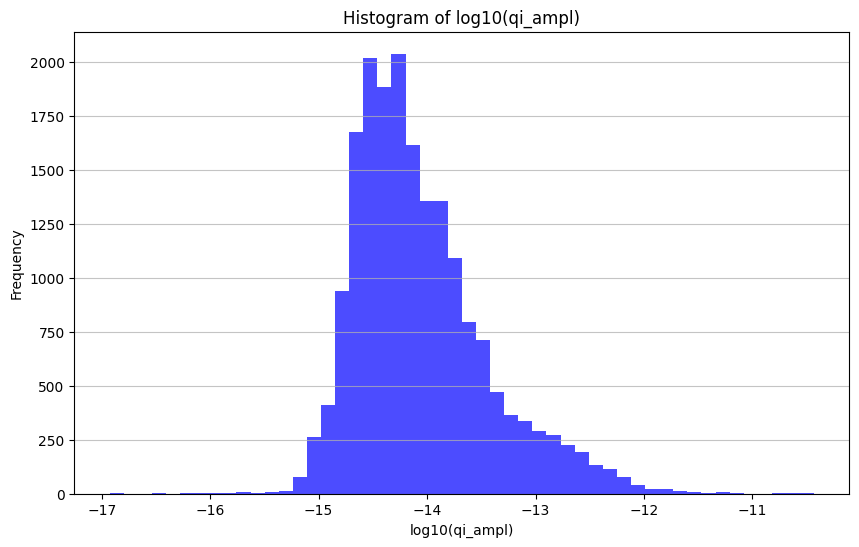

In [12]:
# Creating a histogram of the log10 'qi_ampl' column
plt.figure(figsize=(10, 6))
plt.hist(np.log10(train_df_1018['qi_ampl']), bins=50, color='blue', alpha=0.7)
plt.title('Histogram of log10(qi_ampl)')
plt.xlabel('log10(qi_ampl)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [13]:
# Number of spectra within the log10(qi_ampl) range of -15 to -12 (both included), for the training and inference datasets ...
train_qi_ampl_range = train_df_1018[(np.log10(train_df_1018['qi_ampl']) >= -15) & (np.log10(train_df_1018['qi_ampl']) <= -12)]
inf_qi_ampl_range = inf_df_1018[(np.log10(inf_df_1018['qi_ampl']) >= -15) & (np.log10(inf_df_1018['qi_ampl']) <= -12)]
print(f"Number of spectra in the training set with log10(qi_ampl) between -15 and -12: {len(train_qi_ampl_range)}")
print(f"Number of spectra in the inference set with log10(qi_ampl) between -15 and -12: {len(inf_qi_ampl_range)}")

# ... compared to the total number of spectra in the training and inference datasets
print(f"Total number of spectra in the training set: {len(train_df_1018)}")
print(f"Total number of spectra in the inference set: {len(inf_df_1018)}")

Number of spectra in the training set with log10(qi_ampl) between -15 and -12: 18436
Number of spectra in the inference set with log10(qi_ampl) between -15 and -12: 202913
Total number of spectra in the training set: 18883
Total number of spectra in the inference set: 211552


In [14]:
# Set custom log10(qi_ampl) bins for the histogram, differentiated by class and print the results in a table
bins = np.arange(-14, -11, 0.5)  # Bins for log10(qi_ampl) from -16 to -12
train_df_1018['qi_ampl_bin'] = pd.cut(np.log10(train_df_1018['qi_ampl']), bins=bins)
inf_df_1018['qi_ampl_bin'] = pd.cut(np.log10(inf_df_1018['qi_ampl']), bins=bins)
train_bin_counts = train_df_1018.groupby(['class', 'qi_ampl_bin']).size().unstack(fill_value=0)
inf_bin_counts = inf_df_1018.groupby(['qi_ampl_bin']).size()
print("Training set counts by class and log10(qi_ampl) bins:")
print(train_bin_counts)
print("\nInference set counts by log10(qi_ampl) bins:")
print(inf_bin_counts)

Training set counts by class and log10(qi_ampl) bins:
qi_ampl_bin  (-14.0, -13.5]  (-13.5, -13.0]  (-13.0, -12.5]  (-12.5, -12.0]  \
class                                                                         
1                       983             186              13               1   
2                       392             274             126              37   
3-Car                    21              37              27               3   
3-Cl                      7              23              13               2   
3-K                      10               7               3               1   
3-KNa                    10              13              11               2   
3-OH                      3               9              28               7   
3-P                       5               2               2               0   
4                        67              55              50              38   
5                        30              11               1               0  

## Scaling the spectra

Finally, we can scale the spectra in log10 (or similar). That way, the high-dynamic range shall be more obvious

In [15]:
def qm_scaling(spectrum):

    # Apply a log10 on the spectrum + minimum. If min = 0, convert the resulting NaN values
    # accordingly
    spectrum = np.log10(spectrum + np.abs(np.min(spectrum)))
    spectrum = np.nan_to_num(spectrum, neginf=0)

    # Scale the spectrum to be between 0 and 1
    spectrum = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))
    return spectrum

train_df_1018['spectrum_scaled'] = train_df_1018['spectrum'].apply(qm_scaling)
inf_df_1018['spectrum_scaled'] = inf_df_1018['spectrum'].apply(qm_scaling)

/tmp/ipykernel_20382/349087026.py:5: RuntimeWarning: divide by zero encountered in log10
  spectrum = np.log10(spectrum + np.abs(np.min(spectrum)))
/tmp/ipykernel_20382/349087026.py:9: RuntimeWarning: invalid value encountered in divide
  spectrum = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))


In [29]:
import numpy as np
from scipy.ndimage import uniform_filter1d

def lee_filter_1d(signal, window_size=3, noise_var=None):
    """
    Applies a 1D Lee filter to a signal to reduce noise while preserving edges.
    """
    signal = np.array(signal, dtype=float)
    
    local_mean = uniform_filter1d(signal, size=window_size, mode='reflect')
    local_sqr_mean = uniform_filter1d(signal**2, size=window_size, mode='reflect')
    
    # Clamp to 0 to prevent floating-point negative artifacts
    local_var = np.maximum(local_sqr_mean - local_mean**2, 0)
    
    # Better noise estimation
    if noise_var is None:
        # Avoid using np.min() as it will be 0 on flat areas. 
        # Using a small fraction of the mean variance is a safer dynamic baseline, 
        # but passing an explicit noise_var for your specific sensor is best.
        noise_var = np.mean(local_var) * 0.1 
    
    weights = np.zeros_like(local_var)
    valid_vars = local_var > noise_var
    
    # Calculate W where local variance is higher than noise
    weights[valid_vars] = (local_var[valid_vars] - noise_var) / local_var[valid_vars]
    
    # Apply the filter
    filtered_signal = local_mean + weights * (signal - local_mean)
    
    return filtered_signal

In [30]:
# Apply lee filter on the scaled spectra
train_df_1018['spectrum_lee'] = train_df_1018['spectrum_scaled'].apply(lee_filter_1d)
inf_df_1018['spectrum_lee'] = inf_df_1018['spectrum_scaled'].apply(lee_filter_1d)

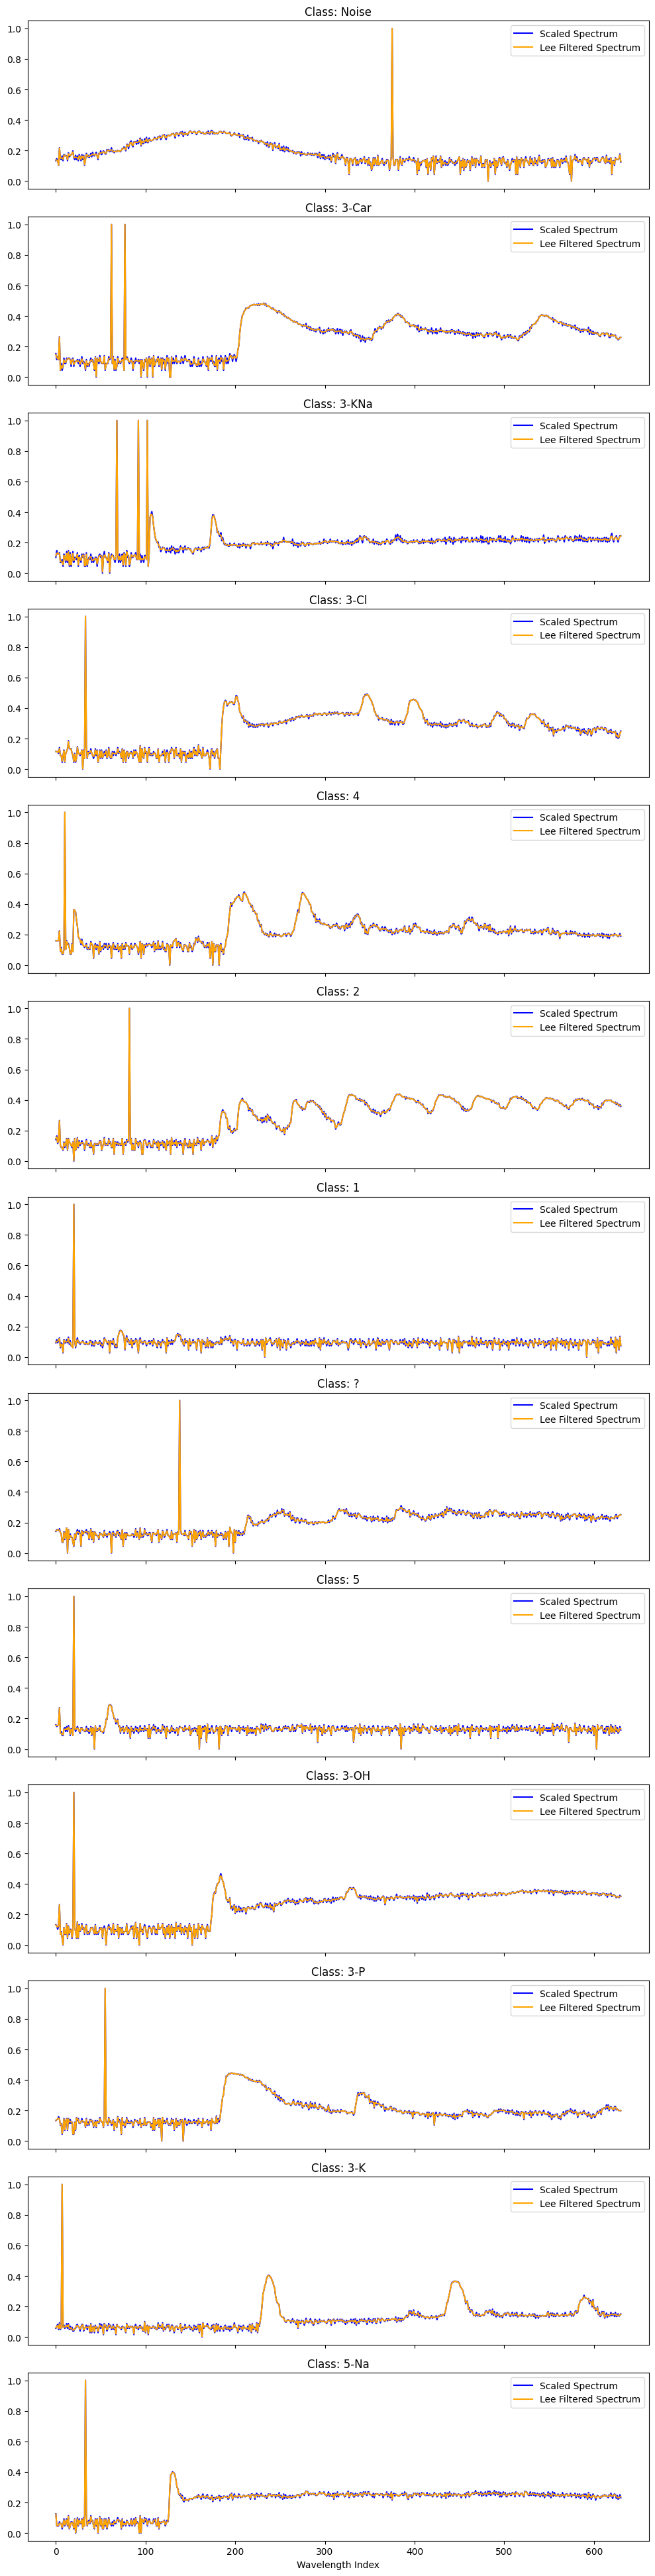

In [32]:
# Plot the first 1 spectrum of each class in the training set in a grid (13 classes). Plot the the scaled spectrum and the lee filtered spectrum
# for each class. Put both spectra in the same plot, separted by class
classes = train_df_1018['class'].unique()
num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 1, figsize=(10, num_classes * 3), sharex=True)
for i, cls in enumerate(classes):
    spectrum_scaled = train_df_1018[train_df_1018['class'] == cls]['spectrum_scaled'].iloc[0]
    spectrum_lee = train_df_1018[train_df_1018['class'] == cls]['spectrum_lee'].iloc[0]
    axes[i].plot(spectrum_scaled, label='Scaled Spectrum', color='blue')
    axes[i].plot(spectrum_lee, label='Lee Filtered Spectrum', color='orange')
    axes[i].set_title(f'Class: {cls}')
    axes[i].legend()
plt.xlabel('Wavelength Index')
plt.tight_layout()
plt.show()